In [2]:
import pandas as pd
import seaborn as sns
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import numpy as np
import math as mth
from scipy import stats as st


In [3]:
order_details = pd.read_csv(r"C:\Users\sasha\Desktop\Pizza_analysis/order_details.csv")
order = pd.read_csv(r"C:\Users\sasha\Desktop\Pizza_analysis/orders.csv")
pizza_types = pd.read_csv(r"C:\Users\sasha\Desktop\Pizza_analysis/pizza_types.csv",header= 0,
                        encoding= 'unicode_escape')
pizzas = pd.read_csv(r"C:\Users\sasha\Desktop\Pizza_analysis/pizzas.csv")

In [ ]:
# обзор
order_details.head(5)
order.head(5)
pizza_types.head(5)
pizzas.head(6)

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [5]:
# сброс дублей и пропусков
def info(data):
    ''' 
    Функция для предварительной обработки датасетов
    '''
    
    print("Дубликатов обнаружено: ", data.duplicated().sum())
    if data.duplicated().sum() >0:
        print('Обнаружены дубликаты, произвожу очистку')
        data = data.drop_duplicates()
        print('Дубликаты ',data.duplicated().sum())
    print()
    print('Пропусков обнаружено:', data.isna().sum())
    print()
    data.info()
    return data
# обзор после сброса дублей и пропусков
order_details = info(order_details)
order = info(order)
pizza_types = info(pizza_types)
pizzas = info(pizzas)
order.info()

Дубликатов обнаружено:  0

Пропусков обнаружено: order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
Дубликатов обнаружено:  0

Пропусков обнаружено: order_id    0
date        0
time        0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int6

In [23]:
# приведение к корректному формату и добавление колонок
order['date'] = pd.to_datetime(order['date'], dayfirst=True)
order.date = pd.to_datetime(order.date)
order['weekday'] = pd.to_datetime(order.date).dt.dayofweek
order.time = pd.to_datetime(order.time)
order.time = order.time.round('H')-timedelta(hours = 1)
order.time = order.time.apply(lambda x:x.time())
order.time = order.time.astype(str)

order.info()

# создание полной таблицы
complete_table = order_details.merge(order,how = 'inner', on = 'order_id')
complete_table = complete_table.merge(pizzas,how = 'inner', on = 'pizza_id')
complete_table = complete_table.merge(pizza_types, how = 'inner', on = 'pizza_type_id')
complete_table['weekday'] = pd.to_datetime(complete_table.date).dt.dayofweek
complete_table['day_name'] = pd.to_datetime(complete_table.date).dt.day_name()
complete_table['month'] = pd.to_datetime(complete_table.date).dt.month
complete_table['month_name'] = pd.to_datetime(complete_table.date).dt.month_name()

complete_table.to_csv('clean_pizza_dataset.csv', index= False)

complete_table.head(5)

C:\Users\sasha\AppData\Local\Temp\ipykernel_12188\2170511486.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order.time = pd.to_datetime(order.time)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  21350 non-null  int64         
 1   date      21350 non-null  datetime64[ns]
 2   time      21350 non-null  object        
 3   weekday   21350 non-null  int32         
 4   hour      21350 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(1)
memory usage: 667.3+ KB


,order_details_id,order_id,pizza_id,quantity,date,time,weekday,hour,pizza_type_id,size,price,name,category,ingredients,day_name,month,month_name
0,1,1,hawaiian_m,1,2015-01-01,09:38:36,3,10,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",Thursday,1,January
1,2,2,classic_dlx_m,1,2015-01-01,09:57:40,3,10,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",Thursday,1,January
2,3,2,five_cheese_l,1,2015-01-01,09:57:40,3,10,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",Thursday,1,January
3,4,2,ital_supr_l,1,2015-01-01,09:57:40,3,10,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",Thursday,1,January
4,5,2,mexicana_m,1,2015-01-01,09:57:40,3,10,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",Thursday,1,January


135.81005586592178


C:\Users\sasha\AppData\Local\Temp\ipykernel_12188\2103458936.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order['hour'] = pd.to_datetime(order['time']).dt.round('H').dt.hour - 1
C:\Users\sasha\AppData\Local\Temp\ipykernel_12188\2103458936.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  order['hour'] = pd.to_datetime(order['time']).dt.round('H').dt.hour - 1


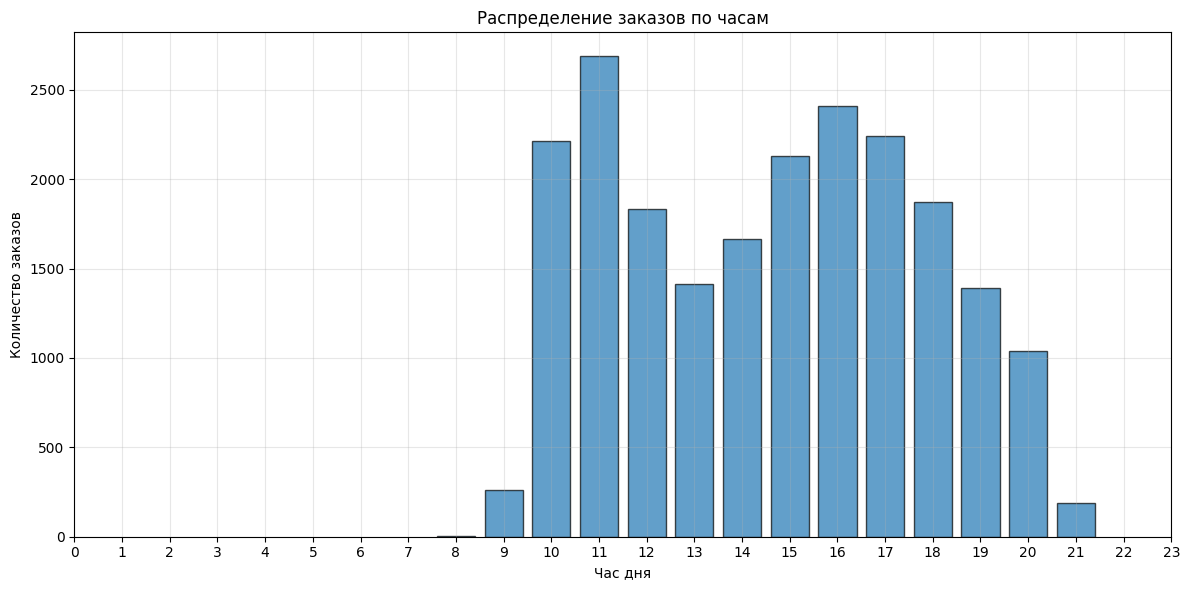

In [15]:
# исследование
# Сколько клиентов в пиццерии каждый день? Есть ли часы пик?
print(complete_table.groupby('date', as_index=False).agg({'order_id':'count'}).order_id.mean())
# Создаем колонку с часом
order['hour'] = pd.to_datetime(order['time']).dt.round('H').dt.hour - 1

# Считаем заказы по часам
hourly_orders = order['hour'].value_counts().sort_index()

# Рисуем
plt.figure(figsize=(12, 6))
plt.bar(hourly_orders.index, hourly_orders.values, edgecolor='black', alpha=0.7)
plt.xticks(range(0, 24))
plt.title('Распределение заказов по часам')
plt.xlabel('Час дня')
plt.ylabel('Количество заказов')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


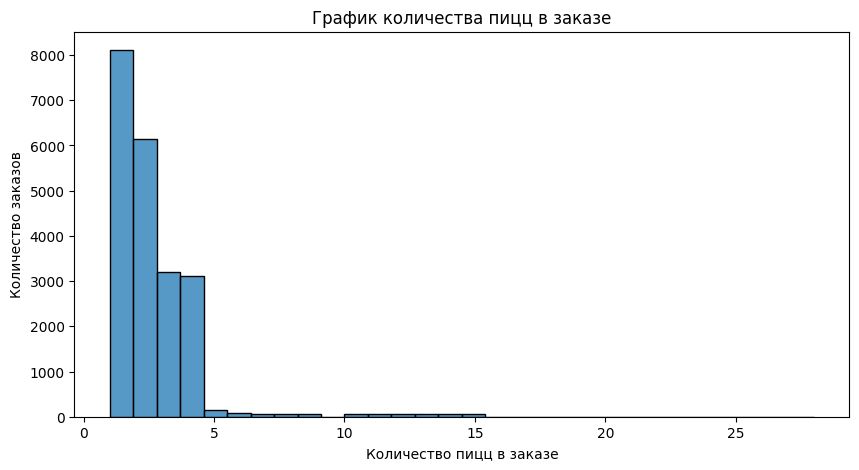

In [16]:
#Сколько пицц обычно находится в заказе? Есть ли бестселлеры?
pizz_in_order =complete_table.groupby('order_id',as_index=False).agg({'quantity':'sum'})

plt.figure(figsize=(10,5))
sns.histplot(pizz_in_order,x = 'quantity',bins=30)
plt.xlabel('Количество пицц в заказе')
plt.ylabel('Количество заказов')
plt.title('График количества пицц в заказе')
plt.show()



In [17]:
# сколлько покупают много пицц в заказе
percentile97 = round(np.percentile(pizz_in_order.quantity,97))
print(percentile97,' и более пицц лишь в 3% заказов')


print('Если убрать выброс, то в среднем в заказе ', round(pizz_in_order.query('quantity < @percentile97').quantity.mean(),2),'пицц')

top_15 = complete_table.name.value_counts().head(15)
top_15 = top_15.reset_index().rename(columns={'index':'name','name':'count'})
top_15

5  и более пицц лишь в 3% заказов
Если убрать выброс, то в среднем в заказе  2.07 пицц


,count,count
0,The Classic Deluxe Pizza,2416
1,The Barbecue Chicken Pizza,2372
2,The Hawaiian Pizza,2370
3,The Pepperoni Pizza,2369
4,The Thai Chicken Pizza,2315
5,The California Chicken Pizza,2302
6,The Spicy Italian Pizza,1887
7,The Sicilian Pizza,1887
8,The Southwest Chicken Pizza,1885
9,The Four Cheese Pizza,1850


In [18]:
#какие размеры пицц предпочитают клиенты

complete_table.groupby('size').agg({'order_id':'count'}).reset_index().rename(columns={'order_id':'order_count'})

,size,order_count
0,L,18526
1,M,15385
2,S,14137
3,XL,544
4,XXL,28


Пиццерия в этом году заработала:  801944.7


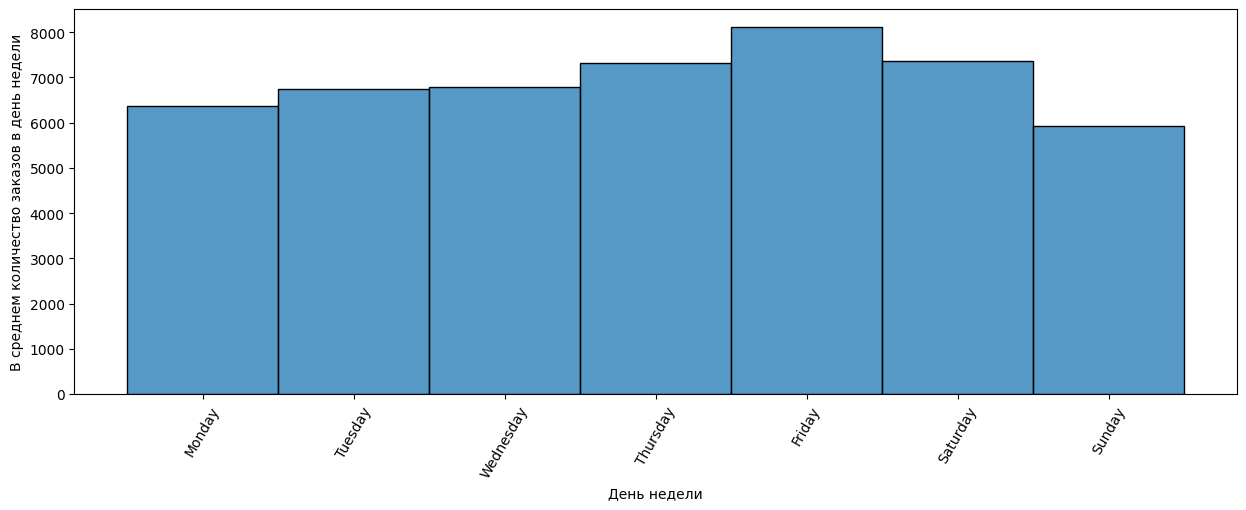

In [19]:
# Сколько денег пиццерия заработала в этом году? Можем ли выявить какую-либо сезонность в продажах?

print('Пиццерия в этом году заработала: ', complete_table.price.sum())

plt.figure(figsize=(15,5))
sns.histplot(complete_table.sort_values(by = 'weekday'),x = 'day_name')
plt.xticks(rotation=60)
plt.ylabel('В среднем количество заказов в день недели')
plt.xlabel('День недели')
plt.show()

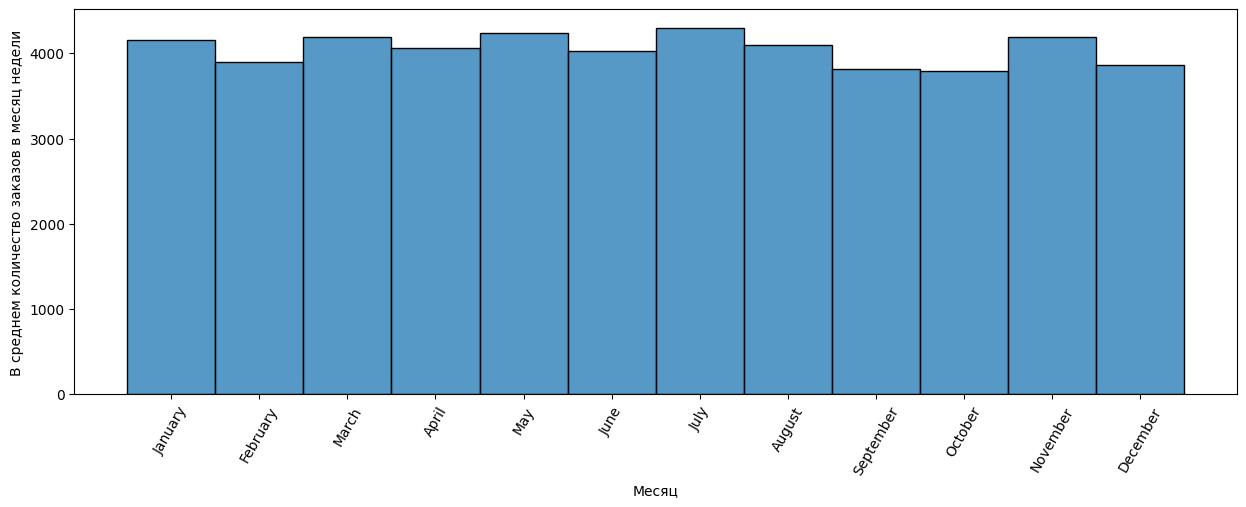

In [ ]:
#Разницы в заказах по месяцам

plt.figure(figsize=(15,5))
sns.histplot(complete_table.sort_values(by = 'month'),x = 'month_name')
plt.xticks(rotation=60)
plt.ylabel('В среднем количество заказов в месяц недели')
plt.xlabel('Месяц')
plt.show()

In [21]:
# Гипотеза 1
#H_0 Большие пиццы в выходные берут так же часто как и в будние дни

#H_1 Количество в заказах больших пицц различается в выходные и будни

def ztest(data_one,second_data):
    alpha = 0.01
    p1 = data_one[0]/second_data[0]
    p2 = data_one[1]/second_data[1]
    
    p_combined = (data_one[0]+data_one[1])/(second_data[0]+second_data[1])
    
    difference = p1-p2
    
    z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/second_data[0] + 1/second_data[1]))
    
    distr = st.norm(0,1)
    
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    print('p-значение: ', p_value)

    if p_value < alpha:
        print('Отвергаем нулевую гипотезу: между долями есть значимая разница')
    else:
        print(
            'Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными') 


pizza_l = complete_table.query('size == "L"')

weekendstr = [5,6]
weekdays = complete_table.query('weekday not in @weekendstr')
weekend = complete_table.query('weekday in @weekendstr')

count_pizz =[weekend.query('size == "L"').quantity.count(),weekdays.query('size == "L"').quantity.count()]
count_orders = [weekend.order_id.count(),weekdays.order_id.count()]

ztest(count_pizz,count_orders)

p-значение:  0.006797178125890202
Отвергаем нулевую гипотезу: между долями есть значимая разница


In [22]:
#Гипотеза 2
#H_0 В будни дни заказы пиццы размера M и L равны

#H_1 В будни дни заказы пиццы размера M и L не равны


count_pizz = [weekdays.query('size == "M"').quantity.count(),weekdays.query('size == "L"').quantity.count()]
count_orders = [weekdays.order_id.count(),weekdays.order_id.count()]

ztest(count_pizz,count_orders)

p-значение:  0.0
Отвергаем нулевую гипотезу: между долями есть значимая разница


In [ ]:
from sqlalchemy import create_engine

df_new = pd.read_csv(r"C:\Users\sasha\Desktop\Pizza_analysis\clean_pizza_dataset.csv", sep=',')
# Переименовываем колонки
df_new.columns = df_new.columns.str.lower()

#подгруз SQL
engine = create_engine('postgresql://postgres@localhost:5432/clean_pizza_dataset')

# Загружаем
df_new.to_sql('clean_pizza_dataset', engine, if_exists='replace', index=False)
print("✅ Готово!")

✅ Готово!
